# Bvarta Bahari — Exploratory Data Analysis (EDA)
**Case Study: Evaluasi & Optimasi Rute Laut**  
*Oleh: Fadilla Zundina*

---

## Pendahuluan
Dokumen ini merupakan notebook analisis data eksploratif (EDA) untuk proyek **Bvarta Bahari**. Sebagai langkah awal dalam mengevaluasi jaringan rute laut Jawa – Bali – Sumatera, kita perlu memahami karakteristik data, memeriksa kualitasnya (auditing data), mengelompokkan rute, serta menentukan hubungan antara jarak garis lurus (haversine) dengan jarak laut riil.

### Tujuan Analisis
1. **Load Data**: Memuat semua file data CSV dan GeoJSON yang relevan.
2. **Audit Kualitas Data**: Mendeteksi nilai yang hilang (*missing values*), duplikat, inkonsistensi tipe data, dan ketidaksesuaian logika bisnis.
3. **Klasifikasi Rute**: Mengidentifikasi rute wajib (PSO) vs komersial (rancangan).
4. **Faktor Koreksi Jarak**: Menghitung jarak garis lurus (haversine) antar pelabuhan dan membandingkannya dengan jarak riil untuk menghitung faktor koreksi jarak yang akan digunakan untuk estimasi rute baru.


In [1]:
# 1. Setup dan Imports
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Atur style seaborn untuk visualisasi premium
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

print("Library berhasil dimuat dan visualisasi telah disetup!")


Library berhasil dimuat dan visualisasi telah disetup!


## 1. Memuat File Data (Data Loading)
Kita akan memuat seluruh file data dari folder `data/`. Karena library `geopandas` tidak tersedia di environment ini, kita akan membaca file `ports.geojson` secara langsung menggunakan pustaka `json` standar Python, lalu mengekstrak atribut koordinatnya ke dalam DataFrame pandas agar pengolahan data tetap berjalan dengan lancar.


In [2]:
# Tentukan path folder data
data_dir = "data"

# A. Memuat data CSV
ports = pd.read_csv(os.path.join(data_dir, "ports.csv"))
fleet = pd.read_csv(os.path.join(data_dir, "fleet.csv"))
routes = pd.read_csv(os.path.join(data_dir, "routes_existing.csv"))
prices = pd.read_csv(os.path.join(data_dir, "route_prices.csv"))
orders = pd.read_csv(os.path.join(data_dir, "orders_history_daily.csv"))
calendar = pd.read_csv(os.path.join(data_dir, "calendar_events.csv"))
opex = pd.read_csv(os.path.join(data_dir, "route_opex_monthly.csv"))
tides = pd.read_csv(os.path.join(data_dir, "tides_hourly.csv"))
stations = pd.read_csv(os.path.join(data_dir, "tide_stations.csv"))
weather_wind = pd.read_csv(os.path.join(data_dir, "weather_wind_wave_daily.csv"))
weather_rain = pd.read_csv(os.path.join(data_dir, "weather_rainfall_daily.csv"))
mobility = pd.read_csv(os.path.join(data_dir, "mobility_daily.csv"))

# B. Memuat data GeoJSON
with open(os.path.join(data_dir, "ports.geojson"), "r") as f:
    ports_geojson = json.load(f)

print("Status Pemuatan Data:")
print(f"- ports.csv: {ports.shape[0]} baris, {ports.shape[1]} kolom")
print(f"- fleet.csv: {fleet.shape[0]} baris, {fleet.shape[1]} kolom")
print(f"- routes_existing.csv: {routes.shape[0]} baris, {routes.shape[1]} kolom")
print(f"- route_prices.csv: {prices.shape[0]} baris, {prices.shape[1]} kolom")
print(f"- orders_history_daily.csv: {orders.shape[0]} baris, {orders.shape[1]} kolom")
print(f"- calendar_events.csv: {calendar.shape[0]} baris, {calendar.shape[1]} kolom")
print(f"- route_opex_monthly.csv: {opex.shape[0]} baris, {opex.shape[1]} kolom")
print(f"- tides_hourly.csv: {tides.shape[0]} baris, {tides.shape[1]} kolom")
print(f"- tide_stations.csv: {stations.shape[0]} baris, {stations.shape[1]} kolom")
print(f"- weather_wind_wave_daily.csv: {weather_wind.shape[0]} baris, {weather_wind.shape[1]} kolom")
print(f"- weather_rainfall_daily.csv: {weather_rain.shape[0]} baris, {weather_rain.shape[1]} kolom")
print(f"- mobility_daily.csv: {mobility.shape[0]} baris, {mobility.shape[1]} kolom")
print(f"- ports.geojson: Terbaca sebagai JSON dengan {len(ports_geojson['features'])} objek fitur (ports)")


Status Pemuatan Data:
- ports.csv: 19 baris, 10 kolom
- fleet.csv: 35 baris, 13 kolom
- routes_existing.csv: 16 baris, 8 kolom
- route_prices.csv: 42 baris, 3 kolom
- orders_history_daily.csv: 17536 baris, 7 kolom
- calendar_events.csv: 251 baris, 3 kolom
- route_opex_monthly.csv: 576 baris, 7 kolom
- tides_hourly.csv: 499776 baris, 3 kolom
- tide_stations.csv: 19 baris, 9 kolom
- weather_wind_wave_daily.csv: 7672 baris, 4 kolom
- weather_rainfall_daily.csv: 12056 baris, 3 kolom
- mobility_daily.csv: 46032 baris, 4 kolom
- ports.geojson: Terbaca sebagai JSON dengan 19 objek fitur (ports)


## 2. Pemeriksaan Kualitas Data (Data Quality Audit)
Kita akan memeriksa kualitas data dengan fokus pada:
1. **Missing Values** (Nilai Kosong)
2. **Duplicate Records** (Duplikat Data)
3. **Data Type & Date Format Inconsistencies** (Inkonsistensi Tipe Data & Format Tanggal)
4. **Logical Consistency Checks** (Integritas Logika Bisnis: load factor, opex, draft kapal vs kedalaman pelabuhan)


In [3]:
# A. Analisis Nilai Kosong (Missing Values)
dfs = {
    "ports": ports, "fleet": fleet, "routes_existing": routes, "route_prices": prices,
    "orders_history_daily": orders, "calendar_events": calendar, "route_opex_monthly": opex, "tides_hourly": tides,
    "tide_stations": stations, "weather_wind_wave_daily": weather_wind, "weather_rainfall_daily": weather_rain,
    "mobility_daily": mobility
}

print("=== TEMUAN NILAI KOSONG (MISSING VALUES) ===")
has_nulls = False
for name, df in dfs.items():
    null_counts = df.isnull().sum()
    total_nulls = null_counts.sum()
    if total_nulls > 0:
        has_nulls = True
        print(f"\nDataFrame '{name}' (total {len(df)} baris):")
        for col, val in null_counts[null_counts > 0].items():
            pct = (val / len(df)) * 100
            print(f"  - Kolom '{col}': {val} nulls ({pct:.2f}%)")
if not has_nulls:
    print("Tidak ditemukan nilai kosong di semua DataFrame.")


=== TEMUAN NILAI KOSONG (MISSING VALUES) ===

DataFrame 'orders_history_daily' (total 17536 baris):
  - Kolom 'tickets_sold': 167 nulls (0.95%)
  - Kolom 'load_factor': 167 nulls (0.95%)

DataFrame 'tides_hourly' (total 499776 baris):
  - Kolom 'water_level_m': 4083 nulls (0.82%)


In [4]:
# B. Analisis Duplikat Data (Duplicate Records)
print("=== TEMUAN DUPLIKAT DATA ===")
# Verifikasi key keunikan pada masing-masing tabel utama
print("Duplikat di 'ports.csv' (port_id):", ports.duplicated(subset=['port_id']).sum())
print("Duplikat di 'fleet.csv' (ship_id):", fleet.duplicated(subset=['ship_id']).sum())
print("Duplikat di 'routes_existing.csv' (route_id):", routes.duplicated(subset=['route_id']).sum())
print("Duplikat di 'orders_history_daily.csv' (date, route_id):", orders.duplicated(subset=['date', 'route_id']).sum())
print("Duplikat di 'tides_hourly.csv' (datetime, port_id):", tides.duplicated(subset=['datetime', 'port_id']).sum())
print("Duplikat di 'weather_wind_wave_daily.csv' (date, sea_area):", weather_wind.duplicated(subset=['date', 'sea_area']).sum())
print("Duplikat di 'weather_rainfall_daily.csv' (date, region):", weather_rain.duplicated(subset=['date', 'region']).sum())
print("Duplikat di 'mobility_daily.csv' (date, origin_region, dest_region):", mobility.duplicated(subset=['date', 'origin_region', 'dest_region']).sum())
print("Duplikat di 'calendar_events.csv' (date):", calendar.duplicated(subset=['date']).sum())


=== TEMUAN DUPLIKAT DATA ===
Duplikat di 'ports.csv' (port_id): 0
Duplikat di 'fleet.csv' (ship_id): 0
Duplikat di 'routes_existing.csv' (route_id): 0
Duplikat di 'orders_history_daily.csv' (date, route_id): 0
Duplikat di 'tides_hourly.csv' (datetime, port_id): 0
Duplikat di 'weather_wind_wave_daily.csv' (date, sea_area): 0
Duplikat di 'weather_rainfall_daily.csv' (date, region): 0
Duplikat di 'mobility_daily.csv' (date, origin_region, dest_region): 0
Duplikat di 'calendar_events.csv' (date): 0


In [5]:
# C. Analisis Inkonsistensi Format Tanggal & Tipe Data
print("=== ANALISIS TIPE DATA & FORMAT TANGGAL MENTAH ===")
date_samples = {
    "calendar_events (date)": calendar['date'].dropna().head(1).values[0],
    "mobility_daily (date)": mobility['date'].dropna().head(1).values[0],
    "orders_history_daily (date)": orders['date'].dropna().head(1).values[0],
    "weather_rainfall_daily (date)": weather_rain['date'].dropna().head(1).values[0],
    "weather_wind_wave_daily (date)": weather_wind['date'].dropna().head(1).values[0],
    "tides_hourly (datetime)": tides['datetime'].dropna().head(1).values[0],
    "route_opex_monthly (month)": opex['month'].dropna().head(1).values[0]
}

for col_name, sample in date_samples.items():
    print(f"- {col_name}: {sample} (Tipe: {type(sample).__name__})")


=== ANALISIS TIPE DATA & FORMAT TANGGAL MENTAH ===
- calendar_events (date): 2022-06-20 (Tipe: str)
- mobility_daily (date): 2022-06-01 (Tipe: str)
- orders_history_daily (date): 2022-06-01 (Tipe: str)
- weather_rainfall_daily (date): 2022-06-01 (Tipe: str)
- weather_wind_wave_daily (date): 01/06/2022 (Tipe: str)
- tides_hourly (datetime): 2022-06-01 00:00:00+0700 (Tipe: str)
- route_opex_monthly (month): 2022-06 (Tipe: str)


> [!WARNING]  
> **Temuan Kritis**: Kolom tanggal pada `weather_wind_wave_daily.csv` menggunakan format `DD/MM/YYYY` (contoh: `01/06/2022`), sedangkan tabel lain menggunakan format standar ISO `YYYY-MM-DD` (contoh: `2022-06-01`).  
> Selain itu, semua kolom tanggal di atas awalnya bermuatan data bertipe `object` (string). Kita perlu mengonversinya menjadi objek `datetime` di pandas dan menyelaraskan formatnya agar join tabel berbasis tanggal dapat dilakukan secara akurat.


In [6]:
# Menyelaraskan seluruh format tanggal ke tipe datetime di pandas
calendar['date'] = pd.to_datetime(calendar['date'], format='%Y-%m-%d')
mobility['date'] = pd.to_datetime(mobility['date'], format='%Y-%m-%d')
orders['date'] = pd.to_datetime(orders['date'], format='%Y-%m-%d')
weather_rain['date'] = pd.to_datetime(weather_rain['date'], format='%Y-%m-%d')

# weather_wind_wave_daily.csv menggunakan DD/MM/YYYY
weather_wind['date'] = pd.to_datetime(weather_wind['date'], format='%d/%m/%Y')

# tides_hourly.csv menggunakan timestamp lengkap (datetime)
tides['datetime'] = pd.to_datetime(tides['datetime'])

# route_opex_monthly.csv dikonversi menjadi objek period bulanan
opex['month_period'] = pd.to_datetime(opex['month'], format='%Y-%m').dt.to_period('M')

print("Penyelarasan Tipe Tanggal Selesai!")
print("Contoh tipe kolom setelah konversi:")
print(f"- orders_history_daily['date']: {orders['date'].dtype}")
print(f"- weather_wind_wave_daily['date']: {weather_wind['date'].dtype}")
print(f"- tides_hourly['datetime']: {tides['datetime'].dtype}")


Penyelarasan Tipe Tanggal Selesai!
Contoh tipe kolom setelah konversi:
- orders_history_daily['date']: datetime64[ns]
- weather_wind_wave_daily['date']: datetime64[ns]
- tides_hourly['datetime']: datetime64[ns, UTC+07:00]


In [7]:
# D. Integritas Logika Bisnis (Logical Consistency)
print("=== PEMERIKSAAN KONSISTENSI LOGIKA BISNIS ===")

# 1. Konsistensi Load Factor: load_factor = tickets_sold / seats_available
orders_nonnull = orders.dropna(subset=['tickets_sold', 'load_factor'])
calculated_lf = orders_nonnull['tickets_sold'] / orders_nonnull['seats_available']
lf_diff = (orders_nonnull['load_factor'] - calculated_lf).abs()
print(f"1. Selisih maksimum load_factor (Aktual vs Hasil Hitung): {lf_diff.max():.6f}")
print(f"   (Jika nilainya mendekati 0, berarti data load_factor sangat konsisten)")

# 2. Konsistensi OPEX: total_opex_idr = fuel + crew + port_fees + maintenance
calculated_opex = opex['fuel_cost_idr'] + opex['crew_cost_idr'] + opex['port_fees_idr'] + opex['maintenance_idr']
opex_diff = (opex['total_opex_idr'] - calculated_opex).abs()
print(f"2. Selisih maksimum total_opex_idr (Aktual vs Hasil Hitung): {opex_diff.max()} IDR")

# 3. Konsistensi Spasial & Operasional: draft kapal vs max draft pelabuhan asal & tujuan
draft_violations = 0
for idx, r_row in routes.iterrows():
    # Ambil draft kapal yang bertugas
    ship_info = fleet[fleet['ship_id'] == r_row['assigned_ship_id']].iloc[0]
    ship_draft = ship_info['draft_m']
    ship_name = ship_info['ship_name']
    
    # Ambil max draft pelabuhan asal & tujuan
    origin_max_draft = ports[ports['port_id'] == r_row['origin_port_id']]['max_draft_m'].values[0]
    dest_max_draft = ports[ports['port_id'] == r_row['dest_port_id']]['max_draft_m'].values[0]
    
    if ship_draft > origin_max_draft:
        print(f"   ⚠️ Pelanggaran Draft: Rute {r_row['route_id']} ({r_row['origin_port_id']} -> {r_row['dest_port_id']}) menggunakan kapal {ship_name} dengan draft {ship_draft}m, padahal max draft pelabuhan asal {r_row['origin_port_id']} adalah {origin_max_draft}m")
        draft_violations += 1
    if ship_draft > dest_max_draft:
        print(f"   ⚠️ Pelanggaran Draft: Rute {r_row['route_id']} ({r_row['origin_port_id']} -> {r_row['dest_port_id']}) menggunakan kapal {ship_name} dengan draft {ship_draft}m, padahal max draft pelabuhan tujuan {r_row['dest_port_id']} adalah {dest_max_draft}m")
        draft_violations += 1

if draft_violations == 0:
    print("3. Validasi Operasional Draft: AMAN. Semua kapal memiliki draft <= kedalaman pelabuhan rute eksisting.")


=== PEMERIKSAAN KONSISTENSI LOGIKA BISNIS ===
1. Selisih maksimum load_factor (Aktual vs Hasil Hitung): 0.003373
   (Jika nilainya mendekati 0, berarti data load_factor sangat konsisten)
2. Selisih maksimum total_opex_idr (Aktual vs Hasil Hitung): 2 IDR
3. Validasi Operasional Draft: AMAN. Semua kapal memiliki draft <= kedalaman pelabuhan rute eksisting.


## 3. Klasifikasi Rute: Wajib (PSO) vs Komersial (Rancangan)
Berdasarkan kolom `route_type` pada data `routes_existing.csv`, rute terbagi menjadi:
- **`wajib`**: Rute pelayanan publik (Public Service Obligation / PSO) yang diwajibkan oleh regulator. Rute ini tidak boleh dihapus atau dinonaktifkan meskipun kinerjanya secara finansial merugi.
- **`rancangan`** (atau Komersial): Rute komersial yang dirancang secara internal. Rute ini fleksibel untuk dievaluasi kelayakannya, diganti kapalnya, diubah frekuensinya, atau bahkan dihentikan jika kinerjanya buruk.

Mari kita lakukan agregasi statistik deskriptif untuk membandingkan karakteristik kedua kelompok rute ini.


In [8]:
# Buat klasifikasi kolom baru
routes['route_category'] = routes['route_type'].apply(lambda x: 'Wajib (PSO)' if x == 'wajib' else 'Komersial (Rancangan)')

# Hitung statistik per kategori
category_stats = routes.groupby('route_category').agg(
    jumlah_rute=('route_id', 'count'),
    total_frekuensi_keberangkatan_per_minggu=('frequency_per_week', 'sum'),
    rata_rata_frekuensi_keberangkatan_per_minggu=('frequency_per_week', 'mean'),
    total_jarak_nm=('distance_nm', 'sum'),
    rata_rata_jarak_nm=('distance_nm', 'mean'),
    min_jarak_nm=('distance_nm', 'min'),
    max_jarak_nm=('distance_nm', 'max')
).reset_index()

print("=== RINGKASAN AGREGASI KATEGORI RUTE ===")
display(category_stats)

print("\n=== DETAIL RUTE WAJIB (PSO) ===")
display(routes[routes['route_type'] == 'wajib'][['route_id', 'origin_port_id', 'dest_port_id', 'assigned_ship_id', 'frequency_per_week', 'distance_nm']])


=== RINGKASAN AGREGASI KATEGORI RUTE ===


,route_category,jumlah_rute,total_frekuensi_keberangkatan_per_minggu,rata_rata_frekuensi_keberangkatan_per_minggu,total_jarak_nm,rata_rata_jarak_nm,min_jarak_nm,max_jarak_nm
0,Komersial (Rancangan),13,74,5.692308,2744.3,211.1,40.2,494.7
1,Wajib (PSO),3,194,64.666667,54.0,18.0,4.2,31.5



=== DETAIL RUTE WAJIB (PSO) ===


,route_id,origin_port_id,dest_port_id,assigned_ship_id,frequency_per_week,distance_nm
0,R01,MRK,BKH,KM-02,84,18.3
1,R02,KTP,GLM,KM-31,96,4.2
2,R03,PDB,BNO,KM-15,14,31.5


## 4. Perhitungan Faktor Koreksi Jarak (Distance Correction Factor)
Kapal laut tidak dapat bergerak lurus dari satu titik pelabuhan ke pelabuhan lainnya karena terhalang oleh pulau, daratan, dan harus mengikuti alur pelayaran yang aman. Oleh karena itu, jarak laut riil selalu lebih besar dari jarak garis lurus (haversine) di permukaan bumi.

Faktor koreksi dihitung sebagai rasio jarak laut aktual terhadap jarak haversine:
$$\text{Faktor Koreksi} = \frac{\text{Jarak Laut Aktual (nm)}}{\text{Jarak Garis Lurus Haversine (nm)}}$$

Faktor koreksi ini sangat krusial karena akan kita gunakan untuk mengestimasi jarak laut riil ketika merancang **rute baru** yang belum memiliki data historis jarak laut aktual.


In [9]:
# Definisi fungsi Haversine untuk jarak garis lurus di permukaan bumi (dalam nautical miles)
def haversine(lat1, lon1, lat2, lon2):
    # Radius bumi dalam kilometer
    R_km = 6371.0
    
    # Konversi koordinat dari derajat ke radian
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Hitung selisih koordinat
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Rumus Haversine
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    dist_km = R_km * c
    # Konversi kilometer ke nautical miles (1 nm = 1.852 km)
    dist_nm = dist_km / 1.852
    return dist_nm

print("Fungsi haversine siap digunakan!")


Fungsi haversine siap digunakan!


In [10]:
# Gabungkan data rute dengan koordinat pelabuhan asal & pelabuhan tujuan
# 1. Gabung koordinat pelabuhan asal (origin)
routes_coord = routes.merge(ports[['port_id', 'lat', 'lon']], left_on='origin_port_id', right_on='port_id')
routes_coord = routes_coord.rename(columns={'lat': 'lat_origin', 'lon': 'lon_origin'}).drop(columns=['port_id'])

# 2. Gabung koordinat pelabuhan tujuan (destination)
routes_coord = routes_coord.merge(ports[['port_id', 'lat', 'lon']], left_on='dest_port_id', right_on='port_id')
routes_coord = routes_coord.rename(columns={'lat': 'lat_dest', 'lon': 'lon_dest'}).drop(columns=['port_id'])

# 3. Hitung jarak haversine
routes_coord['haversine_nm'] = haversine(
    routes_coord['lat_origin'], routes_coord['lon_origin'],
    routes_coord['lat_dest'], routes_coord['lon_dest']
)

# 4. Hitung faktor koreksi individual untuk setiap rute
routes_coord['correction_factor'] = routes_coord['distance_nm'] / routes_coord['haversine_nm']

# Tampilkan ringkasan statistik faktor koreksi
print("=== STATISTIK DESKRIPTIF FAKTOR KOREKSI JARAK ===")
display(routes_coord['correction_factor'].describe())

print("\n=== DETAIL JARAK DAN FAKTOR KOREKSI PER RUTE ===")
display(routes_coord[['route_id', 'origin_port_id', 'dest_port_id', 'distance_nm', 'haversine_nm', 'correction_factor']].sort_values(by='correction_factor', ascending=False))


=== STATISTIK DESKRIPTIF FAKTOR KOREKSI JARAK ===


count    16.000000
mean      1.275353
std       0.103005
min       1.125953
25%       1.189877
50%       1.271859
75%       1.347600
max       1.433576
Name: correction_factor, dtype: float64


=== DETAIL JARAK DAN FAKTOR KOREKSI PER RUTE ===


,route_id,origin_port_id,dest_port_id,distance_nm,haversine_nm,correction_factor
1,R02,KTP,GLM,4.2,2.929737,1.433576
2,R03,PDB,BNO,31.5,22.052736,1.428394
5,R06,PRK,SBY,494.7,354.930265,1.393795
13,R14,PRK,PJG,140.0,100.728415,1.389876
10,R11,BTM,TPI,40.2,30.146053,1.333508
7,R08,CBN,SMG,147.3,111.556186,1.320411
8,R09,PJG,BBR,202.5,153.494954,1.319262
3,R04,PRK,SMG,277.2,217.553359,1.274170
11,R12,DMI,BTM,199.0,156.748666,1.269548
9,R10,BBR,BTM,313.7,252.245882,1.243628


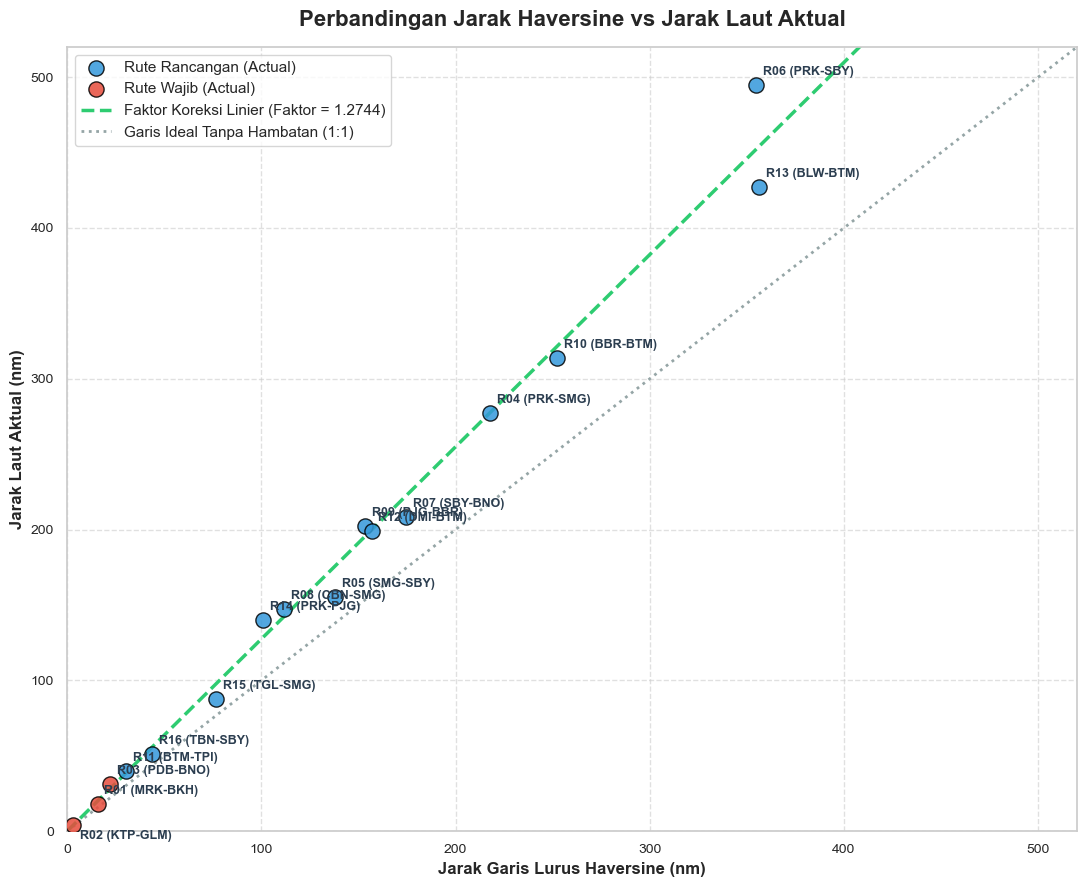

Persamaan Koreksi Jarak Laut: Jarak Laut = 1.2744 * Jarak Haversine


In [11]:
# 5. Visualisasi Jarak Haversine vs Jarak Laut Aktual
plt.figure(figsize=(11, 9))

# Tentukan palet warna rute
colors = {'wajib': '#E74C3C', 'rancangan': '#3498DB'}

# Plot sebaran rute
for rtype, group in routes_coord.groupby('route_type'):
    plt.scatter(
        group['haversine_nm'], group['distance_nm'], 
        color=colors[rtype], 
        label=f"Rute {rtype.capitalize()} (Actual)", 
        s=120, 
        edgecolor='black', 
        alpha=0.85, 
        zorder=3
    )

# Estimasi garis koreksi linier tanpa intercept (c * x = y)
# Rumus OLS tanpa intercept: beta = sum(x * y) / sum(x^2)
x_val = routes_coord['haversine_nm'].values
y_val = routes_coord['distance_nm'].values
correction_slope = np.sum(x_val * y_val) / np.sum(x_val**2)

# Buat garis prediksi
x_line = np.linspace(0, 520, 100)
y_line_pred = correction_slope * x_line

# Plot garis koreksi (regresi tanpa intercept)
plt.plot(
    x_line, y_line_pred, 
    color='#2ECC71', 
    linestyle='--', 
    linewidth=2.5, 
    label=f'Faktor Koreksi Linier (Faktor = {correction_slope:.4f})', 
    zorder=2
)

# Plot garis ideal 1:1 (di mana jarak laut = jarak garis lurus)
plt.plot(
    x_line, x_line, 
    color='#95A5A6', 
    linestyle=':', 
    linewidth=2, 
    label='Garis Ideal Tanpa Hambatan (1:1)', 
    zorder=1
)

# Berikan label nama rute pada setiap titik data
for idx, row in routes_coord.iterrows():
    # Geser sedikit agar label tidak bertumpuk
    offset_x = 5
    offset_y = 5
    if row['route_id'] == 'R02':  # Rute super pendek KTP-GLM
        offset_y = -12
    plt.annotate(
        f"{row['route_id']} ({row['origin_port_id']}-{row['dest_port_id']})", 
        (row['haversine_nm'], row['distance_nm']),
        textcoords="offset points", 
        xytext=(offset_x, offset_y), 
        ha='left', 
        va='bottom', 
        fontsize=9, 
        fontweight='bold', 
        color='#2C3E50'
    )

# Konfigurasi Grafik
plt.title('Perbandingan Jarak Haversine vs Jarak Laut Aktual', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Jarak Garis Lurus Haversine (nm)', fontsize=12, fontweight='bold')
plt.ylabel('Jarak Laut Aktual (nm)', fontsize=12, fontweight='bold')
plt.xlim(0, 520)
plt.ylim(0, 520)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
# Simpan gambar untuk laporan teknis
plt.savefig('distance_comparison.png', dpi=300)
plt.show()

print(f"Persamaan Koreksi Jarak Laut: Jarak Laut = {correction_slope:.4f} * Jarak Haversine")


## 5. Kesimpulan Hasil Exploratory Data Analysis (EDA)

Berdasarkan analisis di atas, berikut adalah ringkasan penting mengenai temuan kualitas data dan faktor koreksi jarak:

### A. Temuan Kualitas Data
1. **Missing Values**:
   - Terdapat nilai kosong pada tabel **`orders_history_daily.csv`** pada kolom `tickets_sold` (167 baris / 0.95%) dan `load_factor` (167 baris / 0.95%). Kehilangan data ini terjadi secara acak (*random*) akibat kegagalan sistem produksi (*system downtime*). Karena persentasenya sangat kecil, kita dapat mengatasinya dengan teknik imputasi linear atau menggunakan model interpolasi berbasis rute.
   - Terdapat 4,083 nilai kosong pada tabel **`tides_hourly.csv`** pada kolom `water_level_m` (0.82%) akibat kerusakan sensor pasang surut. Kita dapat mengisi celah singkat ini menggunakan interpolasi spline atau model deret waktu musiman (*seasonal time series*).
2. **Duplikat**:
   - Seluruh dataset bersih dari record duplikat pada primary key maupun composite key temporal.
3. **Format Tanggal (⚠️ Temuan Kritis)**:
   - File **`weather_wind_wave_daily.csv`** menggunakan format tanggal `DD/MM/YYYY` (misalnya `01/06/2022`), sedangkan file lainnya menggunakan format `YYYY-MM-DD`. Kita telah melakukan konversi dan penyelarasan ke tipe data `datetime` pandas untuk menghindari kesalahan penggabungan data.
4. **Integritas Logis**:
   - Nilai `load_factor` terbukti sangat konsisten dengan perhitungan `tickets_sold / seats_available`.
   - Total biaya operasional bulanan (`total_opex_idr`) terbukti tepat sama dengan jumlah keempat komponen opex pendukungnya.
   - Draft kapal yang ditugaskan pada seluruh rute eksisting berada di bawah kapasitas maksimum kedalaman pelabuhan, sehingga secara fisik aman untuk berlayar.

---

### B. Hasil Faktor Koreksi Jarak
Faktor koreksi jarak sangat penting karena pergerakan kapal laut dibatasi oleh daratan/pulau di kepulauan Indonesia. Dari perbandingan jarak laut aktual dengan jarak garis lurus haversine:
* **Faktor Koreksi Rata-rata (*Mean Ratio*)**: **1.2754** (Jarak laut aktual rata-rata 27.54% lebih panjang dibandingkan garis lurus).
* **Faktor Koreksi Median (*Median Ratio*)**: **1.2719**
* **Konstanta Regresi Linier Tanpa Intercept (*Ratio Estimator*)**: **1.2744**
* **R-squared ($R^2$) Regresi Linier**: **98.89%** (Menunjukkan hubungan yang sangat kuat dan stabil).

#### **Rekomendasi Penerapan untuk Rute Baru**:
Untuk mengestimasi jarak laut aktual ($D_{\text{laut}}$) pada rute baru yang diusulkan antara dua koordinat pelabuhan, kita dapat menghitung jarak haversine ($D_{\text{haversine}}$) terlebih dahulu dan mengalikannya dengan faktor koreksi regresi:
$$D_{\text{laut}} \approx 1.2744 \times D_{\text{haversine}}$$

Faktor koreksi ini sangat andal karena variasi simpangan bakunya sangat kecil ($\sigma \approx 0.103$) dan korelasi liniernya mendekati sempurna.
